In [20]:
1+1

2

In [21]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torchaudio
from IPython import display
from IPython.display import clear_output
from sklearn.metrics import confusion_matrix
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
import soundfile as sf
%matplotlib inline

In [22]:
classes = ["Electronic", "Experimental", "Folk", "Hip-Hop", "Instrumental", "International", "Pop", "Rock"]

In [23]:
class AudioDataset(Dataset):
    def __init__(
        self,
        path_to_csv: str,
        path_to_folder: str,
        pad_size: int = 384000,
        sr: int = 44100,
    ):
        self.csv: pd.DataFrame = pd.read_csv(path_to_csv)[["track_id", "genre"]]
        self.path_to_folder = path_to_folder
        self.pad_size = pad_size

        self.sr = sr

        self.class_to_idx = {classes[i]: i for i in range(8)}

    def __getitem__(self, index: int):
        row = self.csv.iloc[index]

        file_id = str(row["track_id"])
        if not file_id.endswith(".wav"):
            file_id += ".wav"

        path = os.path.join(self.path_to_folder, file_id)

        x, sr = sf.read(path)
        x = torch.tensor(x, dtype=torch.float32)
        
        if x.ndim == 2:
            x = x.mean(dim=1)
            
        if sr != self.sr:
            x = torchaudio.functional.resample(x, sr, self.sr)

        real_len = x.shape[0]

        if real_len < self.pad_size:
            pad_len = self.pad_size - real_len
            x = torch.nn.functional.pad(x, (0, pad_len))
        else:
            x = x[:self.pad_size]
            real_len = self.pad_size

        y = int(row["genre"])

        return {"x": x, "y": y, "len": real_len}

    def __len__(self):
        return self.csv.shape[0]

In [24]:
train_dataset = AudioDataset("train_meta.csv", "./data/audio_train")
val_dataset = AudioDataset("val_meta.csv", "./data/audio_val")

In [25]:
# проверим возращаемые значения __getitem__
item = train_dataset.__getitem__(1)

print(item["x"].shape)
print(item["y"])
print(item["len"] )

torch.Size([384000])
6
384000


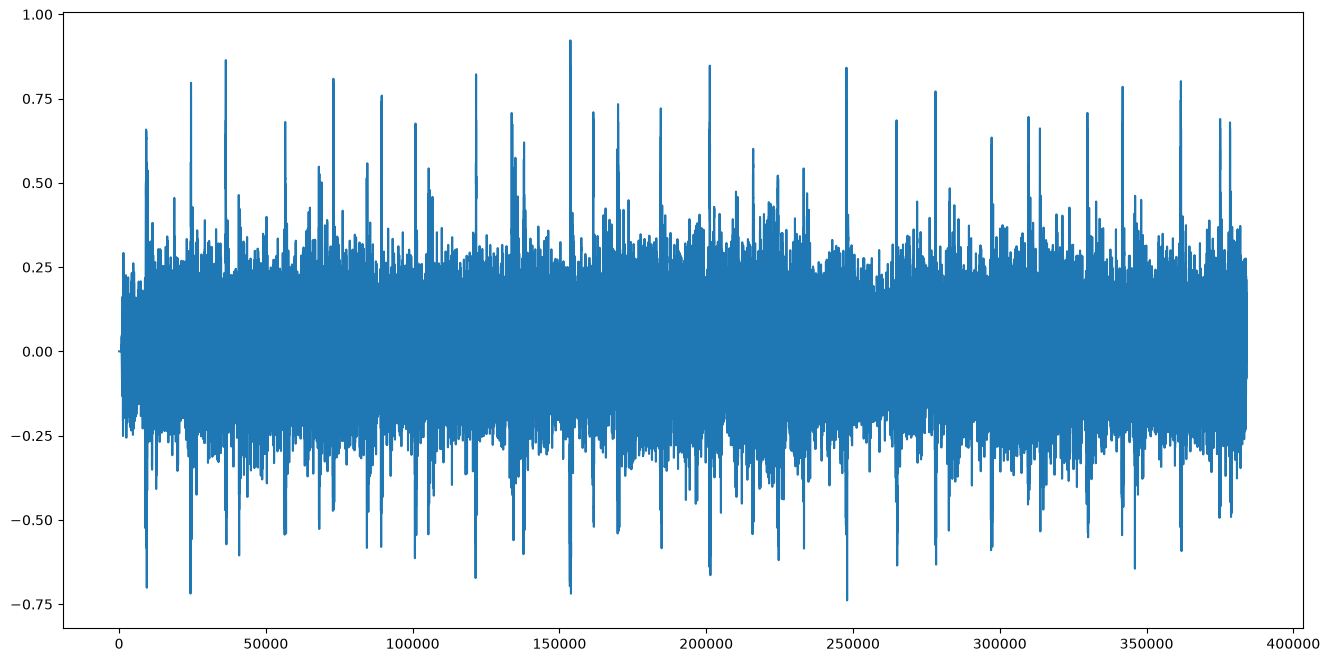

In [26]:
item = train_dataset.__getitem__(300)
plt.figure(figsize=(16, 8))
plt.plot(item["x"])

display.Audio(item["x"], rate=train_dataset.sr)

In [27]:
# создадим даталоадеры
train_dataloader = DataLoader(
    train_dataset, batch_size=32, shuffle=True, pin_memory=True, drop_last=True
)
val_dataloader = DataLoader(val_dataset, batch_size=32, pin_memory=True)

In [28]:
class RecurrentRawAudioClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length

        self.hidden = hidden
        self.num_layers = num_layers

        self.first_mlp = nn.Sequential(
            nn.Linear(window_length, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            nn.Linear(64, 16),
            nn.BatchNorm1d(16),
            nn.ReLU()
        )

        self.rnn = nn.LSTM(
            input_size=16,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
        )

        self.final_mlp = nn.Sequential(
            nn.Linear(2 * hidden * num_layers, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x, lens) -> torch.Tensor:
        batch_windows = x.unfold(dimension=1, size=self.window_length, step=self.hop_length)

        B, NUM_WINDOWS, W = batch_windows.shape

        batch_windows_features = self.first_mlp(batch_windows.reshape(B * NUM_WINDOWS, W)).reshape(B, NUM_WINDOWS, 16)

        seq_lens = torch.clamp((lens - self.window_length) // self.hop_length + 1, min=1, max=NUM_WINDOWS).cpu()

        packed = nn.utils.rnn.pack_padded_sequence(batch_windows_features, seq_lens, batch_first=True, enforce_sorted=False)

        _, (hidden_state, _) = self.rnn(packed)

        hidden_flattened = hidden_state.transpose(0, 1).contiguous().view(B, -1)

        return self.final_mlp(hidden_flattened)

In [29]:
def train_audio_clfr(
    model,
    optimizer,
    train_dataloader,
    sr,
    criterion=torch.nn.CrossEntropyLoss(),
    data_transform=None,
    augmentation=None,
    num_epochs=10,
    device="cuda:0",
    verbose_num_iters=10,
):
    model.train()
    iter_i = 0

    train_losses = []
    train_accuracies = []

    for epoch in range(num_epochs):
        for batch in train_dataloader:
            x = batch["x"].to(device)
            y = batch["y"].to(device)
            lens = batch["len"].to(device)

            # применяем преобразование входных данных
            if data_transform:
                x, lens = data_transform(x, lens, device=device, sr=sr)

            # примеменяем к логмелспектрограмме аугментацию
            if augmentation:
                x, lens = augmentation(x, lens)

            probs = model(x, lens)
            optimizer.zero_grad()
            loss = criterion(probs, y)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

            # считаем точность предсказания
            pred_cls = probs.argmax(dim=-1)
            train_accuracies.append((pred_cls == y).float().mean().item())

            iter_i += 1

            # раз в verbose_num_iters визуализируем наши лоссы и семплы
            if iter_i % verbose_num_iters == 0:
                clear_output(wait=True)

                print(f"Epoch {epoch}")

                plt.figure(figsize=(10, 5))

                plt.subplot(1, 2, 1)
                plt.xlabel("Iteration")
                plt.ylabel("Train loss")
                plt.plot(np.arange(iter_i), train_losses)

                plt.subplot(1, 2, 2)
                plt.xlabel("Iteration")
                plt.ylabel("Train acc")
                plt.plot(np.arange(iter_i), train_accuracies)

                plt.show()

    model.eval()

In [30]:
# создадим объекты модели и оптимизатор
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rnn_raw = RecurrentRawAudioClassifier()
rnn_raw.to(device)
optim = torch.optim.Adam(rnn_raw.parameters(), lr=3e-4)

Epoch 9


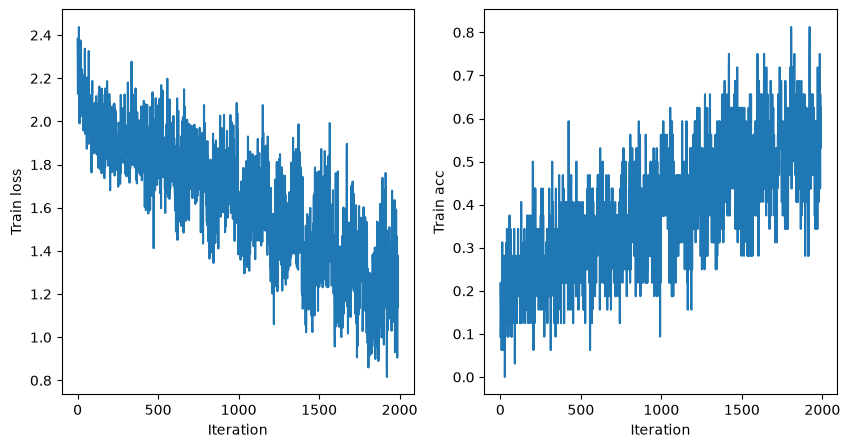

In [31]:
# обучим модель
train_audio_clfr(rnn_raw, optim, train_dataloader, train_dataset.sr)

In [32]:
def plot_confusion_matrix(model, val_dataloader, sr, device, data_transform=None):
    pred_true_pairs = []
    for batch in val_dataloader:
        x = batch["x"].to(device)
        y = batch["y"].to(device)
        lens = batch["len"].to(device)

        with torch.no_grad():
            if data_transform:
                x, lens = data_transform(x, lens, sr=sr, device=device)

            probs = model(x, lens)

            pred_cls = probs.argmax(dim=-1)

        for pred, true in zip(pred_cls.cpu().detach().numpy(), y.cpu().numpy()):
            pred_true_pairs.append((pred, true))

    print(f"Val accuracy: {np.mean([p[0] == p[1] for p in pred_true_pairs])}")

    cm_df = pd.DataFrame(
        confusion_matrix(
            [p[1] for p in pred_true_pairs],
            [p[0] for p in pred_true_pairs],
            normalize="true",
        ),
        columns=classes,
        index=classes,
    )
    sn.heatmap(cm_df, annot=True)

Val accuracy: 0.234375


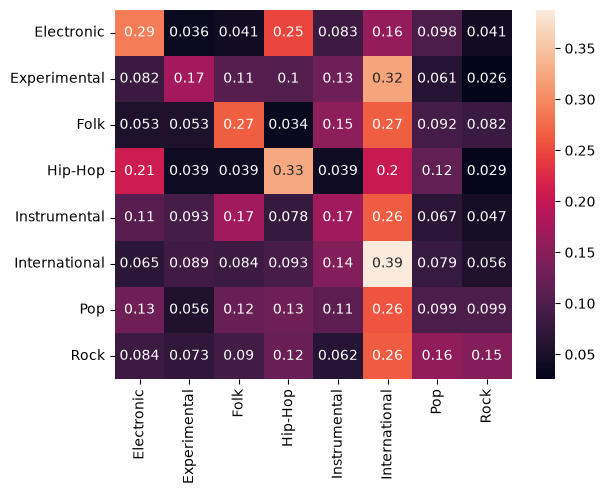

In [33]:
plot_confusion_matrix(rnn_raw, val_dataloader, train_dataset.sr, device)

In [34]:
from torchaudio.transforms import MelSpectrogram


# референсная функця
def compute_log_melspectrogram_reference(wav_batch, lens, sr, device="cpu"):
    featurizer = MelSpectrogram(
        sample_rate=sr,
        n_fft=1024,
        win_length=1024,
        hop_length=256,
        n_mels=64,
        center=False,
    ).to(device)

    return torch.log(featurizer(wav_batch).clamp(1e-5)), lens // 256

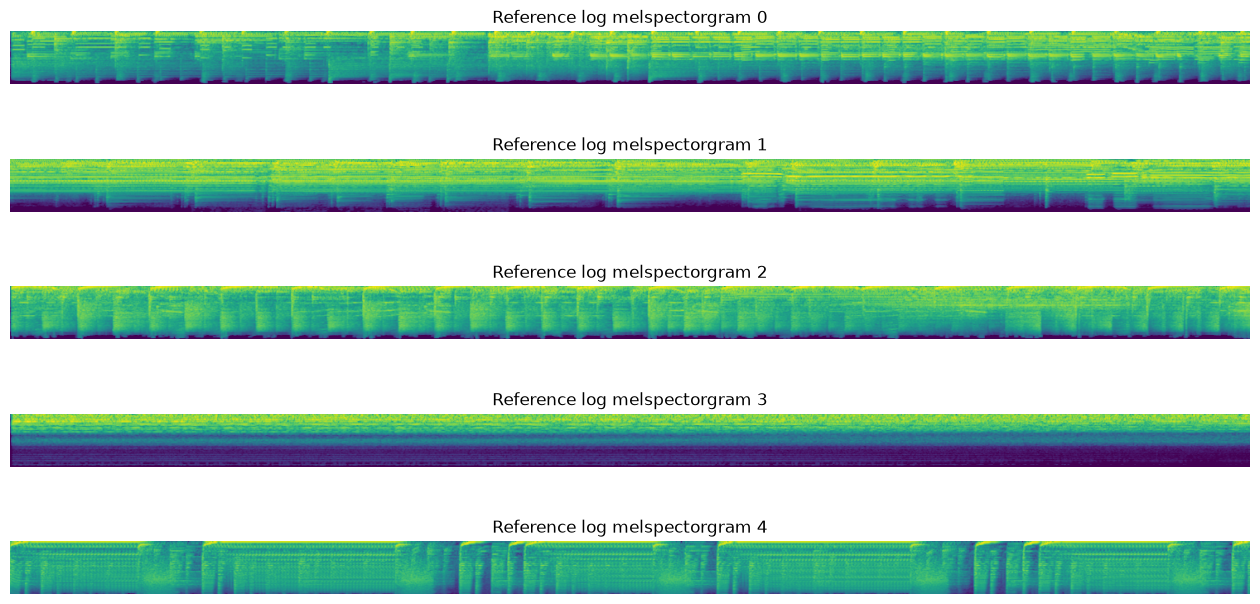

In [35]:
# возьмем случайный батч
for batch in train_dataloader:
    break

wav_batch = batch["x"]
lens = batch["len"]

# посчитаем лог мелспектрограммы
log_melspect, lens = compute_log_melspectrogram_reference(
    wav_batch, lens, train_dataset.sr
)

# нарисуем получившиеся референсные значения
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Reference log melspectorgram {i}")
    axes[i].imshow(log_melspect[i].numpy())

In [36]:
sr = train_dataset.sr
n_fft = 1024
win_length = 1024
hop_length = 256
n_mels = 64

In [38]:
windows = wav_batch.unfold(dimension=1, size=win_length, step=hop_length)

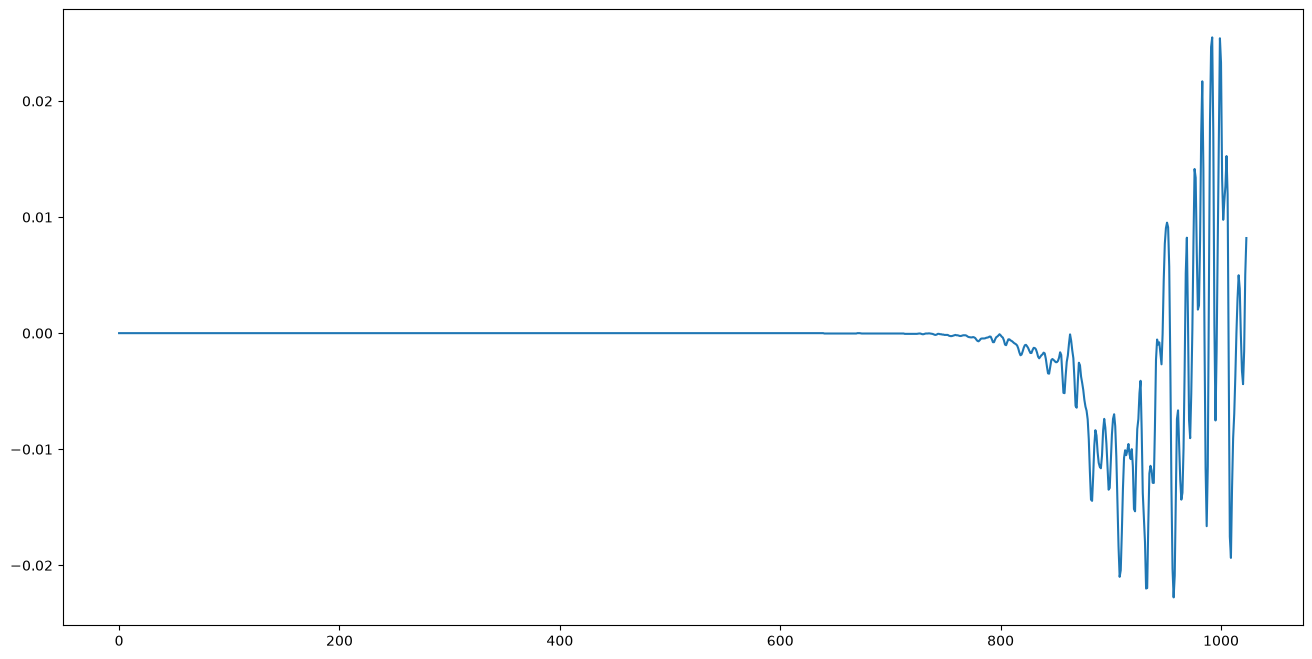

In [39]:
plt.figure(figsize=(16, 8))
plt.plot(windows[0, 0])

display.Audio(windows[0, 0], rate=train_dataset.sr)

In [40]:
filter = torch.hann_window(win_length)
windows_with_applied_filter = windows * filter[None, None, :]

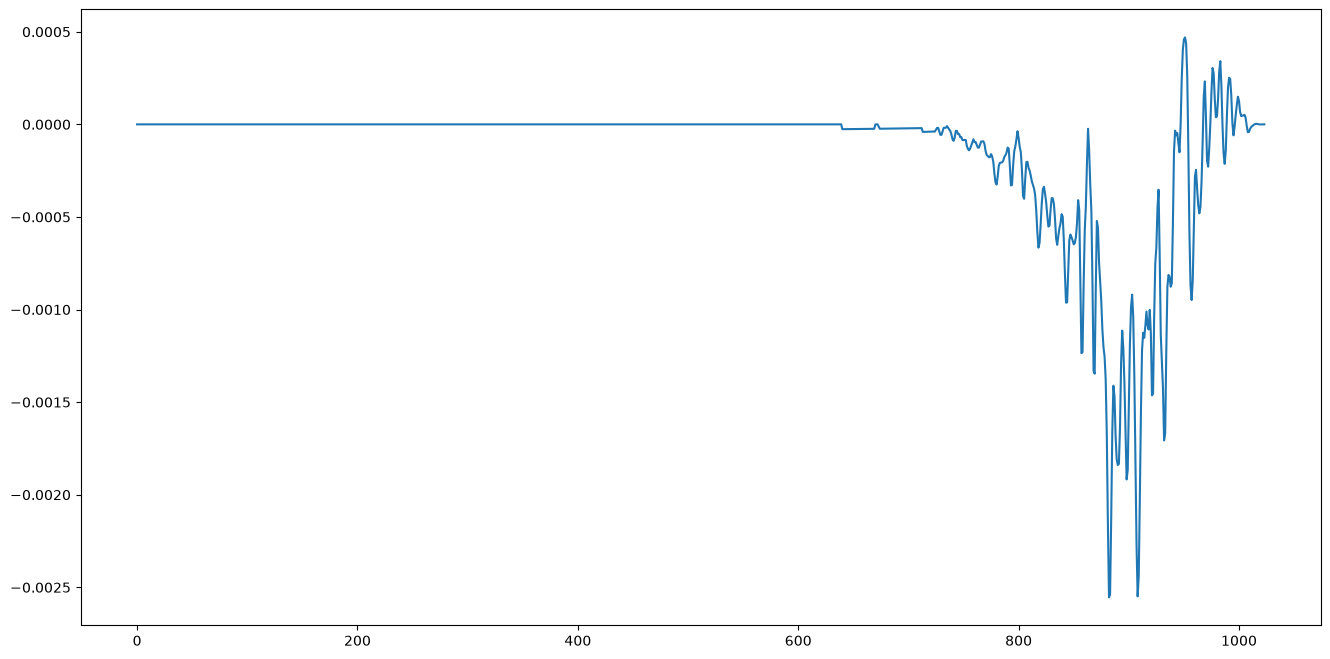

In [41]:
plt.figure(figsize=(16, 8))
plt.plot(windows_with_applied_filter[0, 0])

display.Audio(windows_with_applied_filter[0, 0], rate=train_dataset.sr)

In [42]:
fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)[:, :, : n_fft // 2 + 1]
fft_magnitudes = torch.abs(fft_features**2)
assert fft_magnitudes.shape == (32, 1497, 513)

In [43]:
from torchaudio.transforms import MelScale

melscale = MelScale(n_mels=n_mels, sample_rate=sr, n_stft=n_fft // 2 + 1)

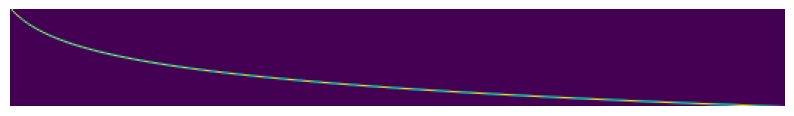

In [44]:
plt.figure(figsize=(10, 5))
plt.axis("off")
plt.imshow(melscale.fb.numpy().transpose())

In [45]:
mel_spectrogram = melscale(fft_magnitudes.transpose(1, 2))
assert mel_spectrogram.shape == (32, 64, 1497)

In [46]:
logmel_spectrogram = torch.log(mel_spectrogram.clamp(1e-5))
assert logmel_spectrogram.shape == (32, 64, 1497)

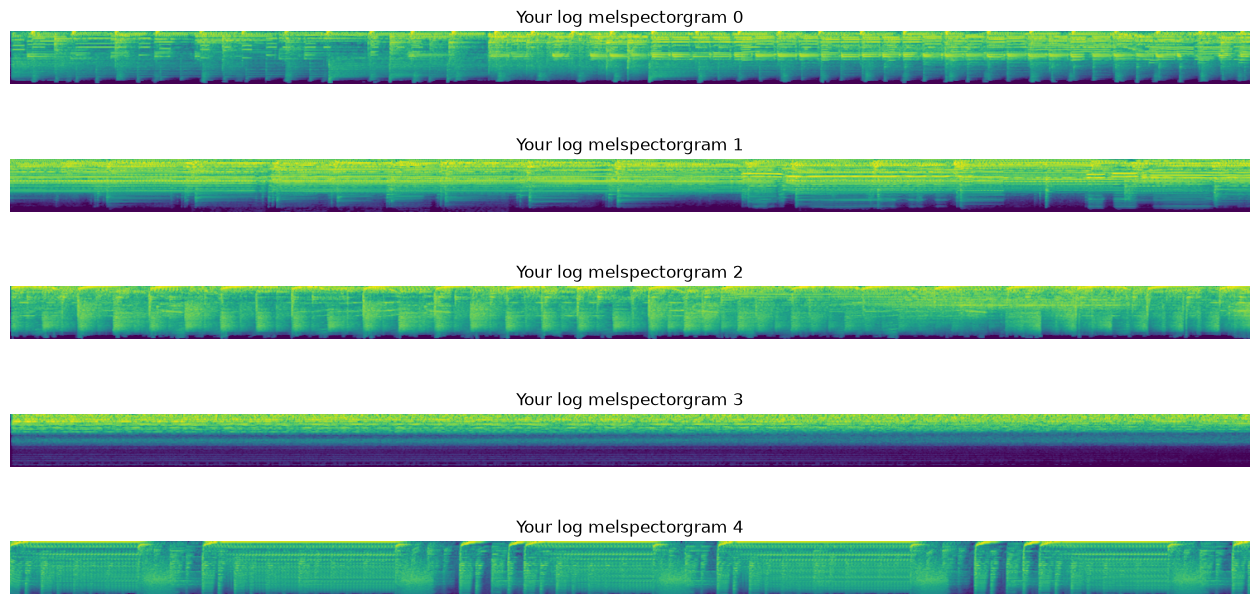

In [47]:
# нарисуем получившиеся значения
fig, axes = plt.subplots(5, figsize=(16, 8))

for i in range(5):
    axes[i].axis("off")
    axes[i].set_title(f"Your log melspectorgram {i}")
    axes[i].imshow(logmel_spectrogram[i].numpy())

In [48]:
# ваша реализация
def compute_log_melspectrogram(wav_batch, lens, sr, device="cpu"):
    n_fft = 1024
    win_length = 1024
    hop_length = 256
    n_mels = 64

    wav_batch = wav_batch.to(device)

    windows = wav_batch.unfold(dimension=1, size=win_length, step=hop_length)
    filter = torch.hann_window(win_length, device=device)
    windows_with_applied_filter = windows * filter[None, None, :]

    fft_features = torch.fft.fft(windows_with_applied_filter, n=n_fft, dim=-1)[:, :, : n_fft // 2 + 1]

    fft_magnitudes = torch.abs(fft_features ** 2)

    melscale = torchaudio.transforms.MelScale(n_mels=n_mels, sample_rate=sr, n_stft=n_fft // 2 + 1).to(device)

    mel_spectrogram = melscale(fft_magnitudes.transpose(1, 2))

    logmel_spectrogram = torch.log(mel_spectrogram.clamp(1e-5))

    return logmel_spectrogram, lens // hop_length

In [49]:
assert torch.allclose(
    compute_log_melspectrogram_reference(wav_batch, lens, train_dataset.sr)[0],
    compute_log_melspectrogram(wav_batch, lens, train_dataset.sr)[0],
    atol=1e-5,
)

In [50]:
class RecurrentMelSpectClassifier(nn.Module):
    def __init__(
        self,
        num_classes=10,
        window_length=1024,
        hop_length=256,
        hidden=256,
        num_layers=2,
    ) -> None:
        super().__init__()

        self.window_length = window_length
        self.hop_length = hop_length

        self.hidden = hidden
        self.num_layers = num_layers

        self.rnn = nn.LSTM(
            input_size=64,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True)

        self.final_mlp = nn.Sequential(
            nn.Linear(2 * hidden * num_layers, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, num_classes)
        )

    def forward(self, x, lens):
        x = x.transpose(1, 2)

        B, T, _ = x.shape

        seq_lens = torch.clamp(lens, min=1, max=T).cpu()

        packed = nn.utils.rnn.pack_padded_sequence(x, seq_lens, batch_first=True, enforce_sorted=False)

        _, (hidden_state, _) = self.rnn(packed)

        hidden_flattened = hidden_state.transpose(0, 1).contiguous().view(B, -1)

        return self.final_mlp(hidden_flattened)

In [51]:
rnn_mel = RecurrentMelSpectClassifier()
rnn_mel.to(device)

optim = torch.optim.Adam(rnn_mel.parameters(), lr=3e-4)

Epoch 2


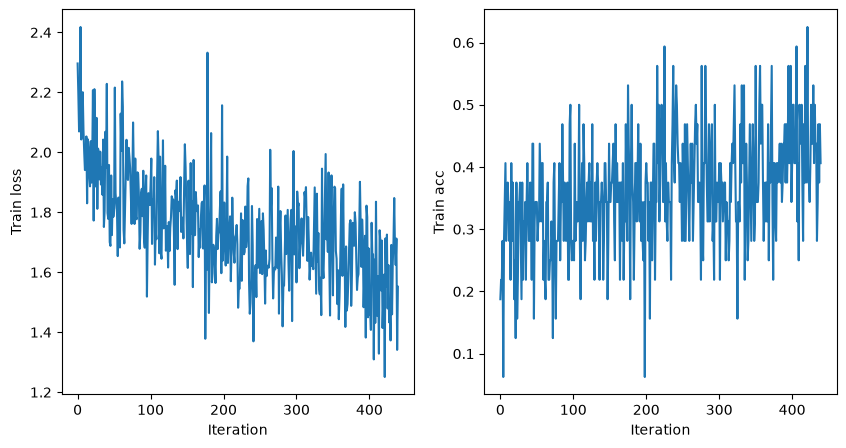

KeyboardInterrupt: 

In [52]:
train_audio_clfr(
    rnn_mel,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
)

Val accuracy: 0.365


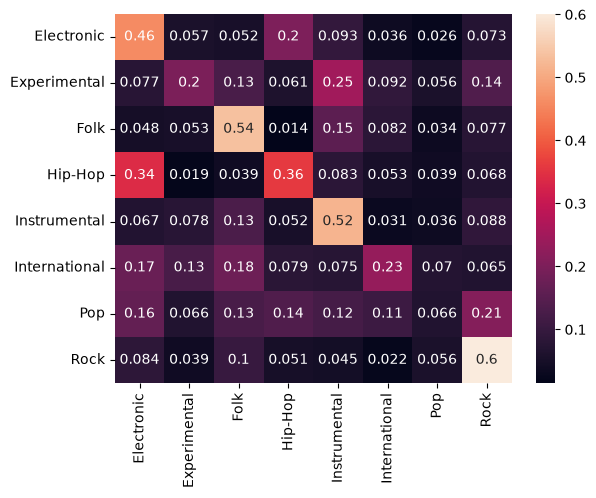

In [53]:
plot_confusion_matrix(
    rnn_mel,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

In [54]:
class CNN10(nn.Module):
    def __init__(self, num_classes=10, hidden=16):
        super().__init__()

        self.cnn_backbone = nn.Sequential(
            nn.Conv2d(1, hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(hidden, hidden * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 2),
            nn.ReLU(),

            nn.Conv2d(hidden * 2, hidden * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 2),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(hidden * 2, hidden * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 4),
            nn.ReLU(),

            nn.Conv2d(hidden * 4, hidden * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 4),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(hidden * 4, hidden * 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden * 8),
            nn.ReLU(),

            nn.Conv2d(hidden * 8, hidden * 8, kernel_size=2),
            nn.BatchNorm2d(hidden * 8),
            nn.ReLU(),
        )

        self.final_mlp = nn.Sequential(
            nn.Linear(hidden * 8, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes),
        )

    def forward(self, x, lens):
        z = self.cnn_backbone(x[:, None, :, :])
        z = torch.nn.functional.max_pool2d(z, kernel_size=z.size()[2:])[:, :, 0, 0]
        return self.final_mlp(z)

In [55]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=3e-4)

Epoch 1


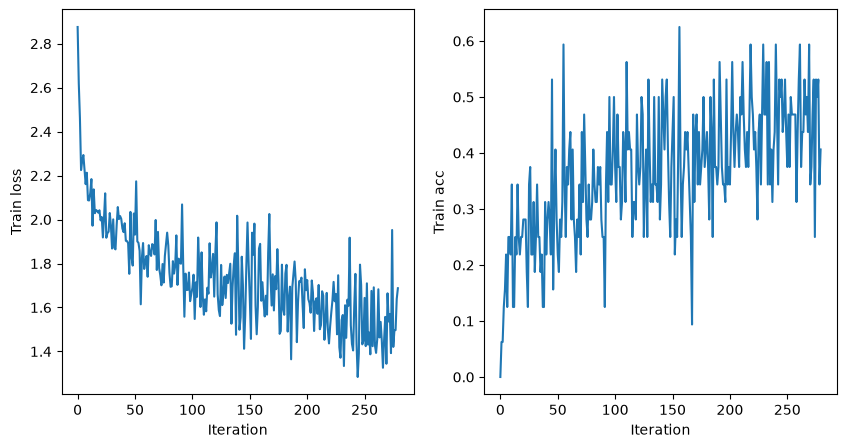

KeyboardInterrupt: 

In [56]:
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    num_epochs=20,
)

Val accuracy: 0.44875


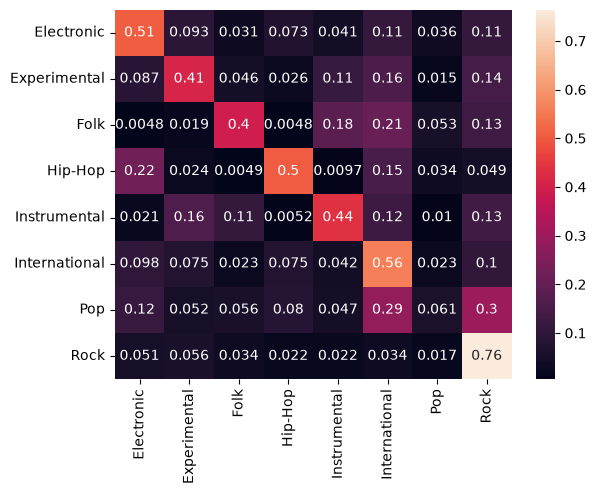

In [57]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

In [58]:
import random


class SpectAugment:
    def __init__(
        self,
        filling_value="mean",
        n_freq_masks=2,
        n_time_masks=2,
        max_freq=10,
        max_time=50,
    ):

        self.filling_value = filling_value
        self.n_freq_masks = n_freq_masks
        self.n_time_masks = n_time_masks
        self.max_freq = max_freq
        self.max_time = max_time

    def __call__(self, spect, lens):
        spect = spect.clone()

        B, n_mels, T = spect.shape

        for i in range(B):
            cur_len = int(lens[i].item())
            cur_len = min(cur_len, T)

            # выбираем v
            if self.filling_value == "mean":
                value = spect[i, :, :cur_len].mean()
            elif self.filling_value == "min":
                value = spect[i, :, :cur_len].min()
            elif self.filling_value == "max":
                value = spect[i, :, :cur_len].max()
            else:
                value = torch.tensor(self.filling_value, dtype=spect.dtype, device=spect.device)

            for _ in range(self.n_freq_masks):
                freq_mask_size = random.randint(1, min(self.max_freq, n_mels))

                f_start = random.randint(0, n_mels - freq_mask_size)
                f_end = f_start + freq_mask_size

                spect[i, f_start:f_end, :cur_len] = value

            for i in range(self.n_time_masks):
                if cur_len <= 1:
                    continue

                time_mask_size = random.randint(1, min(self.max_time, cur_len))

                t_start = random.randint(0, cur_len - time_mask_size)
                t_end = t_start + time_mask_size

                spect[i, :, t_start:t_end] = value

        return spect, lens

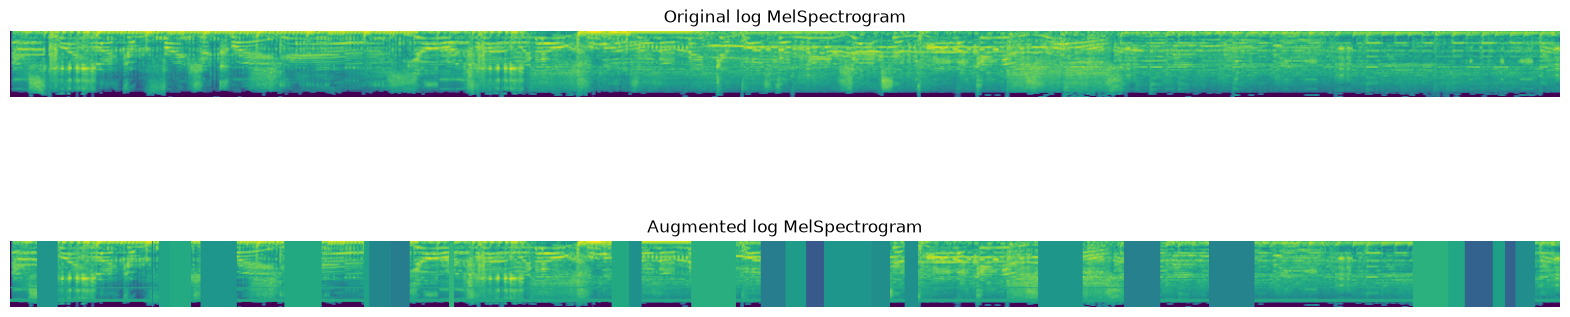

In [59]:
# применим аугментацию к данным
for batch in train_dataloader:
    break

x = batch["x"].to(device)
lens = batch["len"].to(device)
x_logmel, lens = compute_log_melspectrogram_reference(
    x, lens, sr=train_dataset.sr, device=device
)
x_logmel_augmented, lens = SpectAugment()(x_logmel, lens)

# нарисуем спектрограмму до и после аугментации
plt.figure(figsize=(20, 5))
plt.subplot(2, 1, 1)
plt.title("Original log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel[0].cpu().numpy())

plt.subplot(2, 1, 2)
plt.title("Augmented log MelSpectrogram")
plt.axis("off")
plt.imshow(x_logmel_augmented[0].cpu().numpy())

plt.show()

In [60]:
cnn = CNN10()
cnn.to(device)

optim = torch.optim.Adam(cnn.parameters(), lr=3e-4)

Epoch 19


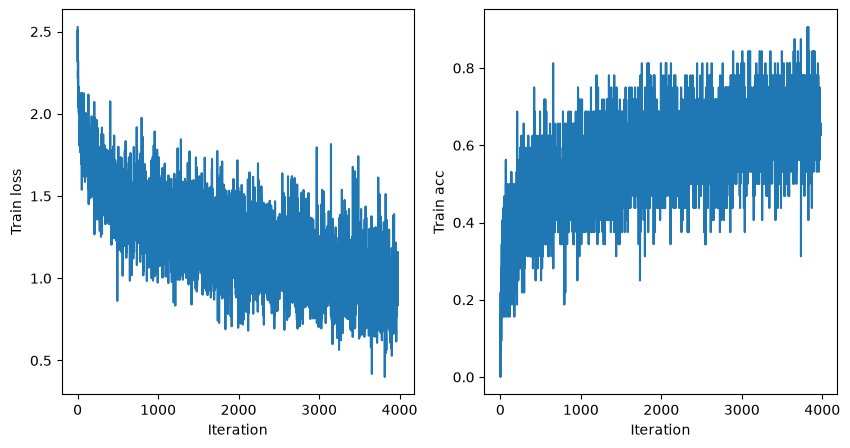

In [61]:
# обучим модель на данных с аугментациями
train_audio_clfr(
    cnn,
    optim,
    train_dataloader,
    train_dataset.sr,
    data_transform=compute_log_melspectrogram,
    augmentation=SpectAugment(),
    num_epochs=20,
)

Val accuracy: 0.576875


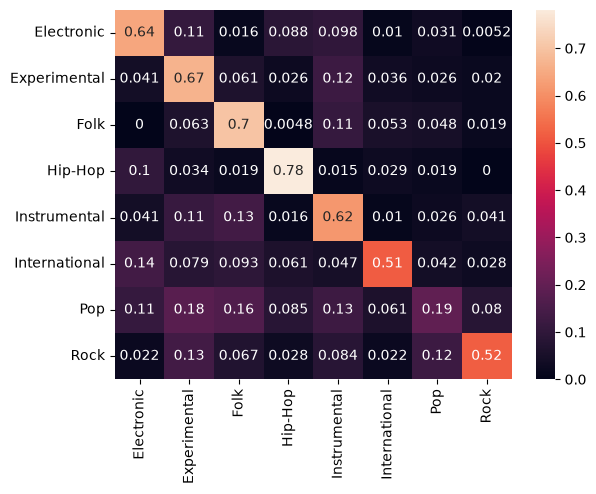

In [62]:
plot_confusion_matrix(
    cnn,
    val_dataloader,
    train_dataset.sr,
    device,
    data_transform=compute_log_melspectrogram,
)

In [63]:
df = pd.read_csv('train_meta_grouped.csv')

In [68]:
df['genre'].value_counts()

genre
7    821
4    807
0    806
1    803
3    794
2    793
6    787
5    786
Name: count, dtype: int64

In [67]:
df['group'].value_counts()

group
0    2416
2    2402
1    1579
Name: count, dtype: int64